<a href="https://colab.research.google.com/github/juanpajedrez/learn_rag_Huggingface/blob/main/MultiModal_RAG_Video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1  - Setup

In [ ]:
from google.colab import userdata
api_key = userdata.get('ai_agent_openai')

In [ ]:
%cd /content/drive/MyDrive/ai_agents_zero_to_mastery/RAG Bootcamp/RAG/Multimodal RAG

/content/drive/MyDrive/ai_agents_zero_to_mastery/RAG Bootcamp/RAG/Multimodal RAG


In [ ]:
from pathlib import Path
Path.cwd().exists()

True

# Step 2 -  Get the data

In [ ]:
# Define the video path
video_path = Path().cwd() / "decision-making-course.mp4"
video_path.exists()

True

# Step 3 - Extract Audio and Compress

In [ ]:
# Install libraries
!pip install -1 pydub
!apt-get install -q ffmpeg


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: -1
Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.


In [ ]:
# Import libraries
import os
import subprocess
from pydub import AudioSegment

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


In [ ]:
# Define the audio path
audio_output_path = Path().cwd() / "audios" / "output.mp3"

In [ ]:
# Ensure the output path directory exists
output_dir = audio_output_path.parent
output_dir.mkdir(exist_ok=True, parents=True)

In [ ]:
# Ensure the output file has the correct extension
if not audio_output_path.suffix == ".mp3":
  audio_output_path = audio_output_path.with_suffix(".mp3")

In [ ]:
# Construct the ffmpeg command to extract the audio
command = [
    'ffmpeg',
    '-y', # overwrites if the audio exists
    '-i', str(video_path), # input file
    '-vn', # No video
    '-acodec', 'libmp3lame', # Audio codecs
    str(audio_output_path), # output file
]

In [ ]:
# Execute the command to extract the audio
subprocess.run(command, check=True)

CompletedProcess(args=['ffmpeg', '-y', '-i', '/content/drive/MyDrive/ai_agents_zero_to_mastery/RAG Bootcamp/RAG/Multimodal RAG/decision-making-course.mp4', '-vn', '-acodec', 'libmp3lame', '/content/drive/MyDrive/ai_agents_zero_to_mastery/RAG Bootcamp/RAG/Multimodal RAG/audios/output.mp3'], returncode=0)

In [ ]:
# Set the bitrate
# NOTE = Bitrate -> Frequency sample * bit depth * Number of channels (2 for stereo)
bitrate = "32k"

In [ ]:
# Set path for compressed audio
compressed_audio_path = Path().cwd() / "audios" / "output_compressed.mp3"

In [ ]:
# Construct the ffmpeg command to compress the audio
command = [
    'ffmpeg',
    '-y', # overwrites if the audio exists
    '-i', str(audio_output_path), # input file
    '-ab', bitrate, # bit rate
    str(compressed_audio_path), # output file
]

In [ ]:
subprocess.run(command, check=True)

CompletedProcess(args=['ffmpeg', '-y', '-i', '/content/drive/MyDrive/ai_agents_zero_to_mastery/RAG Bootcamp/RAG/Multimodal RAG/audios/output.mp3', '-ab', '32k', '/content/drive/MyDrive/ai_agents_zero_to_mastery/RAG Bootcamp/RAG/Multimodal RAG/audios/output_compressed.mp3'], returncode=0)

# Step 4 - Transcribe Audio using OpenAI API

In [ ]:
!pip install -q openai

In [ ]:
# Library
from openai import OpenAI

In [ ]:
# Connect the script to the API
client = OpenAI(api_key=api_key)

In [ ]:
# Open the compressed file in binary mode
with open(compressed_audio_path, "rb") as file:
  # Use the Whisper model to transcribe
  transcript = client.audio.transcriptions.create(
      model="whisper-1",
      file=file,
  )

In [ ]:
# Inspect the transcript
transcript.text[0:500]

"Are you looking to improve the way that you make decisions? Do you sometimes worry that you don't have all the tools to make the best calls? Or even when you hear other people at work, you sometimes feel, hmm, that does not feel like the right decision, but at the same time, you cannot explain why. Well, I think you are in the right place. In the next one hour, you will have a crash course on decision making, problem solving and critical thinking. I'm going to share with you framework thinking, "

In [ ]:
# Define the path where the transcription will be saved
transcription_path = Path().cwd() / "transcripts" / "transcript.txt"

# Save the transcribed text to file
with open(transcription_path, "w") as file:
  file.write(transcript.text)

# Step 5 - Extract the frames.

In [ ]:
!pip install -q moviepy

In [ ]:
# Load library
from moviepy.editor import VideoFileClip

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':



In [ ]:
# Degine output folder
output_folder = Path().cwd()/ "frames"
if not output_folder.exists():
  output_folder.mkdir(parents=True, exist_ok=True)

In [ ]:
# Load the video
video = VideoFileClip(str(video_path))

In [ ]:
# Extract the frames
from tqdm import tqdm
frame_paths = []

# Let's extract 60 frames per second, so a loooot of data.
# Therefore, we can limit the amount of data we need
interval = 10
total_frames = int((video.duration)/interval) + 1

for t in tqdm(range(0, int(video.duration), interval), desc = "Iterating across frames...", total = total_frames):
  frame_path = output_folder / f"frame_{t:04d}.png"

  # Save the frame at the specified time
  if not frame_path.exists():
    video.save_frame(str(frame_path), t)
  frame_paths.append(str(frame_path))

Iterating across frames...: 100%|██████████| 373/373 [00:00<00:00, 1513.84it/s]


# Step 6 - Embedding Audio.

In [ ]:
# Import libraries
from transformers import CLIPProcessor, CLIPModel, CLIPTokenizer
import torch
import numpy as np

In [ ]:
# Load the Model, Processor and Tokenizer
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")

The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(



config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [ ]:
# Get the transcribed text
with open(transcription_path, "r") as file:
  transcript_text = file.read()

In [ ]:
transcript_text

"Are you looking to improve the way that you make decisions? Do you sometimes worry that you don't have all the tools to make the best calls? Or even when you hear other people at work, you sometimes feel, hmm, that does not feel like the right decision, but at the same time, you cannot explain why. Well, I think you are in the right place. In the next one hour, you will have a crash course on decision making, problem solving and critical thinking. I'm going to share with you framework thinking, how we make decisions and cognitive biases. I'm going to show you some very well-known frameworks like system one and system two thinking, loss aversion, and even some cognitive biases like anchoring bias or confirmation bias. By the end of this one hour, you will have better tools to make decisions. And at the same time, just to give you some nudge to actually complete, there is a very nice incentive. So I have a tiny gift for you at the end of this crash course. Are you ready? Let's get start

In [ ]:
# Tokenize the entire text
tokens = tokenizer(transcript_text,
                   return_tensors = "pt",
                   padding = True)
tokens = tokens['input_ids'][0]
print(f"The number of tokens is {len(tokens)}")

Token indices sequence length is longer than the specified maximum sequence length for this model (9887 > 77). Running this sequence through the model will result in indexing errors


The number of tokens is 9887


In [ ]:
# The CLIP model requires 77 tokens per chunk
max_tokens = 77
transcription_chunks = []

for i in range(0, len(tokens), max_tokens):
  chunk = tokens[i:i+max_tokens]
  transcription_chunks.append(chunk)

print(f"The number of chunks is: {len(transcription_chunks)}")

The number of chunks is: 129


In [ ]:
# Text Embeddings -> Embedd the tokens in each chunk
text_embeddings = []

for chunk in tqdm(transcription_chunks, desc = "Getting text embeddings...", total = len(transcription_chunks)):
  # Ensure the chunk is in the correct shape
  inputs = {"input_ids": chunk.unsqueeze(0)}

  # Get the text embedding
  with torch.inference_mode():
    text_embedding = model.get_text_features(**inputs)
    text_embeddings.append(text_embedding['pooler_output'].cpu().numpy().flatten())

# Convert the list of embeddings to a numpy array
text_embedding_np = np.array(text_embeddings)

Getting text embeddings...: 100%|██████████| 129/129 [00:51<00:00,  2.50it/s]


In [ ]:
# Print the dimensions and embeddings necessary
print(f"The torch text single embedding shape is: {transcription_chunks[0].shape}, dtype: {transcription_chunks[0].dtype}")
print(f"The numpy text embeddings shape is: {text_embedding_np.shape}, dtype: {text_embedding_np.dtype}")

The torch text single embedding shape is: torch.Size([77]), dtype: torch.int64
The numpy text embeddings shape is: (129, 512), dtype: float32


# Step 7 -  embedding the images

In [ ]:
from PIL import Image

In [ ]:
# Embedd the images
frames_folder_path = Path().cwd() / "frames"
image_embeddings = []

# Let's get all filenames
all_files_paths = list(frames_folder_path.glob("*"))

for frame_path in tqdm(all_files_paths, desc = "Getting the image embeddings...", total = len(all_files_paths)):
  if frame_path.suffix == ".png":
    # Load and preprocess the image
    image = Image.open(frame_path)
    inputs = processor(images = image, return_tensors = "pt")

    # Pass it to the model to obtain image embeddings
    with torch.inference_mode():
      image_embedding = model.get_image_features(**inputs)
      image_embeddings.append(image_embedding['pooler_output'].cpu().numpy().flatten())

# Cast them into numpy
image_embedding_np = np.array(image_embeddings)

Getting the image embeddings...: 100%|██████████| 373/373 [02:36<00:00,  2.39it/s]


In [ ]:
# Print the dimensions and embeddings necessary
test_img = Image.open(all_files_paths[0])

# Print all of the dimensions and types of image embeddings
print(f"The image torch single embedding shape is: {test_img.size}, type: {type(test_img)}")
print(f"The image numpy embedding shape is: {image_embedding_np.shape}, dtype: {image_embedding_np.dtype}")

The image torch single embedding shape is: (1280, 720), type: <class 'PIL.PngImagePlugin.PngImageFile'>
The image numpy embedding shape is: (373, 512), dtype: float32


# Step 8 - Contrastive Learning

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import random

In [ ]:
# Calculate the cosine similarity matrix
similarity_matrix = cosine_similarity(text_embedding_np, image_embedding_np)

In [ ]:
similarity_matrix.shape

(129, 373)

In [ ]:
# Retrieve the top-k similar images for each text chunk
top_k = 5
for i , text_chunk in enumerate(similarity_matrix):
  similar_indices = text_chunk.argsort()[-top_k:][::-1] # Starting from the last one to the first one
  print(f"Top {top_k} images for each chunk: {i}: {similar_indices}")

Top 5 images for each chunk: 0: [ 94 300 258  21  34]
Top 5 images for each chunk: 1: [ 10 233 204 203 123]
Top 5 images for each chunk: 2: [205 325 359 114  95]
Top 5 images for each chunk: 3: [ 12  11 329 154  13]
Top 5 images for each chunk: 4: [ 80  12  61 237 120]
Top 5 images for each chunk: 5: [ 17 333 372 327 343]
Top 5 images for each chunk: 6: [225 200 226 349 336]
Top 5 images for each chunk: 7: [305 200  13   9  65]
Top 5 images for each chunk: 8: [357  68 352 355 351]
Top 5 images for each chunk: 9: [179 351 178  47 352]
Top 5 images for each chunk: 10: [239 240 241 238 179]
Top 5 images for each chunk: 11: [ 33 225 248 326  13]
Top 5 images for each chunk: 12: [ 78  79 346 355 351]
Top 5 images for each chunk: 13: [ 11  12  13 108 255]
Top 5 images for each chunk: 14: [341 134 135 336 133]
Top 5 images for each chunk: 15: [ 78  80 139 133 140]
Top 5 images for each chunk: 16: [265 264 236 237 170]
Top 5 images for each chunk: 17: [203 204 178 225  53]
Top 5 images for eac

In [ ]:
# Set a random seed for reproducibility
random.seed(1502)

# Select 5 random text chunk indices
random_text_indices = random.sample(range(len(text_embedding_np)), 5)
print(f"Random text chunk indices: {random_text_indices}")

Random text chunk indices: [43, 122, 67, 110, 89]


In [ ]:
# Find the 3 most similar images for each text
text_to_images_similarities = []
for idx in random_text_indices:
  similar_images = similarity_matrix[idx].argsort()[-3:][::-1] # Get the top 3 and invert everything
  text_to_images_similarities.append(similar_images)

Text chunk: 1: that it can inter fere with system 2 thinking , even when we consciously try to focus on something else . the st roo p effect can be extremely important when making presentations , as it highlights the influence of non - verbal cues and the way information is presented on our ability to process information accurately . for example , imagine you are making a presentation to a group of stakeholders , and you use a


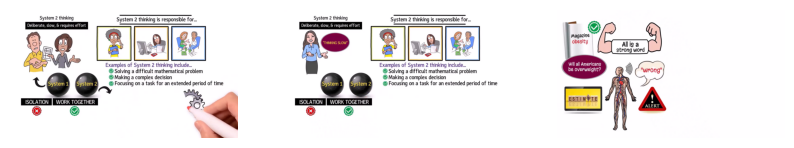

Text chunk: 2: tile . the stores that were there in 1 9 1 6 were not the same as the ones in 1 9 2 2 . they would still be below average , but would no longer be the bottom performers . the same insight was similar in all industries . according to se christ , medi ocr ity tends to prevail in the conduct of competitive business . what se christ was so critical of is now


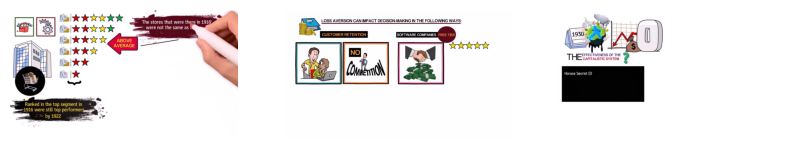

Text chunk: 3: you 're sure to make a choice that will make you more satisfied and happier . until the next video , have fun ! hey there , super excited to dive into the fascinating world of cognitive bi ases with you today . and , you know , it 's kind of funny how we humans think we 're like so smart and rational , but the truth is we 're all suscep tible to these bi


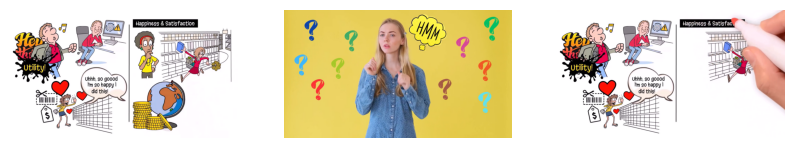

Text chunk: 4: this and conclude , well , being in silicon valley is doing wonders for them . maybe we should move there too . so we would have more companies coming to silicon valley , potentially leading to more tech innovation . so we have point a , which leads to point b , which once more leads to point a . this is called the mutual cau sal ity bias or reverse cau sal ity . it


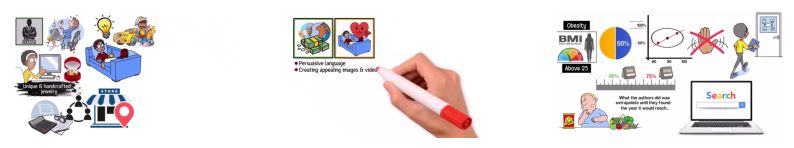

Text chunk: 5: found a year it would reach 1 0 0 %. now , you could say , okay , dio go , this is ridiculous , no one would extra pol ate like this . to which i reply , well , go check for yourself . go to google and search for , will all americans be overweight ? and it should be one of the first hits . it is quite obvious that you can 't


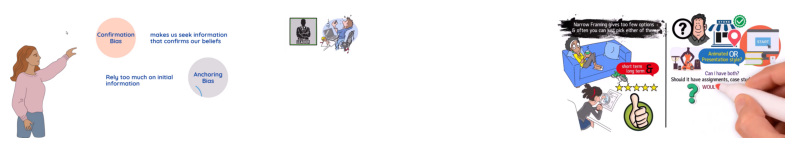

In [ ]:
# Data visualization of the text and images
for i, text_idx in enumerate(random_text_indices):
  plt.figure(figsize = (10, 8))

  # Displaying the text chunk with a print
  print(f"Text chunk: {i + 1}: {" ".join(
      [tokenizer.decode([token]) for token in transcription_chunks[text_idx]])
  }")
  for j, image_idx in enumerate(text_to_images_similarities[i]):
    image = Image.open(all_files_paths[image_idx])
    plt.subplot(1, 3, j + 1)
    plt.imshow(image)
    plt.axis("off")
  plt.show()


# Step 9 - Retrieval System

In [ ]:
# Let's define a query
query = "Which cognitive biases are discussed?"

In [ ]:
# Tokenizing the query
query_tokens = tokenizer(query,
                         return_tensors = "pt",
                         padding=True)["input_ids"]

In [ ]:
# Generate the query embeddings in the join embedding space
# Use the clip model
with torch.inference_mode():
  query_embedding = model.get_text_features(
      input_ids = query_tokens
  )['pooler_output'].cpu().numpy().flatten()
print(f"The shape of the query embedding is: {query_embedding.shape}")

The shape of the query embedding is: (512,)


In [ ]:
# Compute the cosine similarity between the query and the transcripts
cos_similarities_query_text = cosine_similarity([query_embedding], text_embedding_np)[0]

In [ ]:
# Define how many chunks we want
top_k_text = 10

# Retrieve the indices of the top-k most similar text-chunks
top_k_text_indices = cos_similarities_query_text.argsort()[-top_k_text:][::-1]
top_k_text_indices

array([128,  74,   0,  46,  92, 123,  15,  65,  78,  37])

In [ ]:
# Retrieve the closes images for each text chunk
top_k_images_indices = []
number_of_images_per_chunk = 2

for idx in top_k_text_indices:
  similar_images = similarity_matrix[idx].argsort()[-number_of_images_per_chunk:][::-1]
  top_k_images_indices.append(similar_images)

# Remove any duplicates and limit to top k images
top_k_images_indices = list(set([item for sublist in top_k_images_indices for item in sublist]))
print(f"The total images indices are {len(top_k_images_indices)}")

The total images indices are 17


# Step 10 - Generation System

In [ ]:
import base64

In [ ]:
# Combining the retrieved text chunks
retrieved_text = []
for idx in top_k_text_indices:
  retrieved_text.append(tokenizer.decode(transcription_chunks[idx]))
retrieved_text = " ".join(retrieved_text)
retrieved_text

"you have any stories on decision making that you think are thought - provoking or interesting , please do share . i love to hear other people 's stories . <|endoftext|> fatally shot two people and wounded two others aboard a public bus in fort lauderdale , florida , on thursday afternoon near the city 's police headquarters , the authority said . now , based on this news article , what is your view on it ? please pause here and formulate an answer . now , for sure , where we all agree is that this is a tragedy . people are dead and wounded <|startoftext|>are you looking to improve the way that you make decisions ? do you sometimes worry that you don 't have all the tools to make the best calls ? or even when you hear other people at work , you sometimes feel , hmm , that does not feel like the right decision , but at the same time , you cannot explain why . well , i think you are in the right place other . participants are asked to perform two tasks at the same time , such as counting

In [ ]:
# Convert the images and append them
base64frames = []
for idx in top_k_images_indices:
  image_path = all_files_paths[idx]
  with open(image_path, "rb") as image_file:
    base64_image = base64.b64encode(image_file.read()).decode("utf-8")
    base64frames.append(base64_image)

In [ ]:
# Define the mode answer system prompt
MODEL = "gpt-5.4-mini"
system_prompt = """
You are an expert teacher that summarizes visual and transcribed content
"""

In [ ]:
# Prepare tge yser nessage content
user_message_content = [
    "The are the frames from the video",
    *map(lambda x: {"type": "image_url",
                      "image_url": {"url": f"data:image/jpg;base64, {x}",
                                    "detail": "high"}},
         base64frames),
    {"type": "text",
     "text": retrieved_text}
]

In [ ]:
# Call the OpenAI API to generate a summary
response = client.chat.completions.create(
    model = MODEL,
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_message_content},
    ],
    temperature = 0.3,
)

In [ ]:
import IPython
from IPython.display import display, Markdown

In [ ]:
# Generate the response
generated_response = response.choices[0].message.content
display(Markdown(generated_response))

Here’s a concise summary of the video frames:

## Main topic
The video explains **loss aversion** and how it affects **decision-making**, especially in situations involving **risk, uncertainty, and cognitive biases**.

## Key ideas shown
- **Risk vs. uncertainty**
  - Risk = outcomes can be estimated numerically.
  - Uncertainty = outcomes are unknown or hard to quantify.

- **Gambles and probability**
  - One example compares two gambles:
    - Gamble A: win $1 if you draw a red ball, with a known probability.
    - Gamble B: win $1 if you draw a black ball, but the number of black balls is unknown.
  - This illustrates how people prefer known probabilities over unknown ones.

- **Critical thinking**
  - The video encourages:
    - seeking diverse sources,
    - questioning beliefs,
    - practicing critical thinking,
    - avoiding confirmation bias.

- **Cognitive biases**
  - Several biases are listed, including:
    - confirmation bias
    - anchoring bias
    - linear bias
    - survivorship bias
    - selection bias
    - mutual causality bias
    - gambler’s fallacy
    - regression to the mean

- **System 1 vs System 2**
  - **System 1**: fast, automatic, intuitive.
  - **System 2**: slow, deliberate, effortful.
  - The video emphasizes that better decisions often require **System 2 thinking** and that it works best when it “works together” with System 1 rather than in isolation.

- **Loss aversion examples**
  - Loss aversion affects:
    - **customer retention**
    - **software free tiers**
    - **competition avoidance**
    - **loyalty building**
  - People are often more motivated to avoid losses than to achieve equivalent gains.

- **Narrow framing**
  - The video warns against evaluating decisions too narrowly, because that can distort judgment.

## Overall message
The video’s message is that **people often make biased decisions because they fear losses more than they value gains**, and that improving decisions requires **awareness of biases, critical thinking, and deliberate System 2 reasoning**.

If you want, I can also turn this into:
1. a **shorter 3-sentence summary**,  
2. **study notes**, or  
3. a **bullet list of all concepts mentioned**.